# 📚 Notebook 3 — Öğrenci Modeli + Knowledge Distillation
## AFETSONAR • Calamitas AI • Teknofest 2025

---

## 🎯 Bu Notebook Ne Yapıyor?

Phase 2'de eğittiğimiz **büyük öğretmen** (`SiameseTeacherSegformerV3`, B3 backbone, ~85M params) kullanarak çok daha küçük bir **öğrenci** (`StudentSiameseSegformerB0`, B0 backbone, ~4-5M params) eğitiyoruz.

Amaç: **drone'da çalışabilecek kadar küçük ve hızlı** bir model. Knowledge Distillation (KD) ile öğretmenin bilgisini öğrenciye aktarıyoruz.

## 🧮 5-Component KD Loss

$$
\mathcal{L}_{total} = 0.30\,\mathcal{L}_{hard} + 0.40\,\mathcal{L}_{KD\_soft} + 0.15\,\mathcal{L}_{feature} + 0.10\,\mathcal{L}_{KD\_change} + 0.05\,\mathcal{L}_{KD\_disaster}
$$

| # | Bileşen | Ağırlık | Ne İşe Yarar |
|---|---------|---------|--------------|
| 1 | `L_hard` | **0.30** | Öğrenci ↔ GT (Lovász+Dice+Focal = Phase 2'deki `ComboDamageLossV3`) |
| 2 | `L_KD_soft` | **0.40** | Damage logit KD (KL div, T=4) |
| 3 | `L_feature` | **0.15** | Encoder feature MSE (1×1 projection ile) |
| 4 | `L_KD_change` | **0.10** | Change logit KD (KL div, T=4) |
| 5 | `L_KD_disaster` | **0.05** | Disaster classification KD (KL div, T=4) |

## 🔑 Phase 2 API'leriyle Uyum

Bu notebook Phase 2 koduna **birebir** uyumlu yazıldı:
- `XBDDatasetV2(csv_path=..., mode="teacher", ...)` — her iki modelin de input'u öğretmenin beklediği **6-kanal concat** `[pre, post]` formatında
- `model(image)` — yani 6-kanal tek tensor
- Dataset dict keys: `image`, `mask`, `disaster_idx`, `filename`
- Change mask collate_fn içinde `derive_change_mask_v2` ile türetiliyor
- `damage_logits` öğretmende **list** (deep supervision); KD'de ana (ilk) logit kullanılıyor
- EMA API: `ema.update(model)`, `ema.apply_to(model) → backup`, `ema.restore(model, backup)`

## 🎯 Hedef

- Öğretmen `mIoU_no_bg` ≈ **0.470**
- Hedef öğrenci `mIoU_no_bg` ≥ **0.85 × 0.470 ≈ 0.40**
- Boyut: **15-20×** küçük
- Latency: drone için real-time

## ⚙️ Eğitim Ayarları (Plan v2)

- **Epochs:** 60
- **Batch:** H100'de 16 micro × 3 accum = 48 effective
- **Resolution:** 768
- **Precision:** bf16
- **Optimizer:** AdamW
- **LR:** Manuel (Phase 1 v2 pattern — scheduler yok)
- **EMA:** epoch 5'ten itibaren

---
> 💡 **Beginner Notu:** Her hücrenin başında **"Bu hücre ne yapıyor?"**, **"Beklenen çıktı"**, **"Hata olursa"** bölümleri var.


In [1]:
# ============================================================
# HÜCRE 2: Drive mount + GPU kontrol + path sanity
# ============================================================
# Bu hücre ne yapıyor?
#   1) Google Drive'ı mount eder
#   2) GPU'yu tespit eder (H100 beklenir) ve batch/accum ayarlar
#   3) AFETSONAR klasörlerini ve Phase 2 teacher checkpoint'ini kontrol eder
#
# Beklenen çıktı:
#   - "✅ Drive bağlandı"
#   - "NVIDIA H100 ..., VRAM ~80 GB"
#   - "✓ teacher_v4_best_ema.pth bulundu"
#
# Hata olursa:
#   - "No GPU" → Runtime > Change runtime type > H100
#   - "teacher_v4_best_ema.pth yok" → Phase 2'yi çalıştır

from google.colab import drive
drive.mount('/content/drive', force_remount=False)

import os
import torch

PROJECT_ROOT = "/content/drive/MyDrive/AFETSONAR"
DATA_RAW     = os.path.join(PROJECT_ROOT, "data/raw/xview2")
DATA_MASKS   = os.path.join(PROJECT_ROOT, "data/processed/masks")
DATA_SPLITS  = os.path.join(PROJECT_ROOT, "data/splits")
SRC_DIR      = os.path.join(PROJECT_ROOT, "src")
CKPT_TEACHER = os.path.join(PROJECT_ROOT, "checkpoints/teacher")
CKPT_STUDENT = os.path.join(PROJECT_ROOT, "checkpoints/student")
OUTPUTS_VIZ  = os.path.join(PROJECT_ROOT, "outputs/visualizations")

os.makedirs(CKPT_STUDENT, exist_ok=True)
os.makedirs(OUTPUTS_VIZ, exist_ok=True)

# === Klasör kontrolü ===
for p in [DATA_SPLITS, SRC_DIR, CKPT_TEACHER]:
    assert os.path.exists(p), f"❌ Yok: {p}"
print("✅ AFETSONAR klasörleri OK")

# === Teacher checkpoint ===
TEACHER_CKPT_PATH = os.path.join(CKPT_TEACHER, "teacher_v4_best_ema.pth")
assert os.path.exists(TEACHER_CKPT_PATH), f"❌ Teacher yok: {TEACHER_CKPT_PATH}"
print(f"✅ Teacher: teacher_v4_best_ema.pth ({os.path.getsize(TEACHER_CKPT_PATH)/1e6:.0f} MB)")

# === GPU ===
assert torch.cuda.is_available(), "❌ GPU yok!"
gpu_name = torch.cuda.get_device_name(0)
vram_gb = round(torch.cuda.get_device_properties(0).total_memory / 1024**3, 1)
bf16_supported = torch.cuda.is_bf16_supported()
print(f"\n⚙️  {gpu_name}, VRAM: {vram_gb} GB")

# Student Siamese + Teacher Siamese (KD) = yaklaşık Phase 2 x1.3 bellek
if "H100" in gpu_name:
    BATCH_SIZE = 16
    GRAD_ACCUM_STEPS = 3
    NUM_WORKERS = 8
elif "A100" in gpu_name:
    BATCH_SIZE = 8
    GRAD_ACCUM_STEPS = 6
    NUM_WORKERS = 6
elif "L4" in gpu_name or "V100" in gpu_name:
    BATCH_SIZE = 4
    GRAD_ACCUM_STEPS = 12
    NUM_WORKERS = 4
elif "T4" in gpu_name:
    BATCH_SIZE = 2
    GRAD_ACCUM_STEPS = 24
    NUM_WORKERS = 2
else:
    BATCH_SIZE = 4
    GRAD_ACCUM_STEPS = 12
    NUM_WORKERS = 4

EFFECTIVE_BATCH = BATCH_SIZE * GRAD_ACCUM_STEPS
PRECISION = "bf16" if bf16_supported else "fp16"
device = torch.device("cuda")
IMAGE_SIZE = 768

print(f"\n📊 Notebook 3 Ayarlar:")
print(f"  micro batch     = {BATCH_SIZE}")
print(f"  grad accum      = {GRAD_ACCUM_STEPS}")
print(f"  effective batch = {EFFECTIVE_BATCH}")
print(f"  image size      = {IMAGE_SIZE}")
print(f"  precision       = {PRECISION}")


Mounted at /content/drive
✅ AFETSONAR klasörleri OK
✅ Teacher: teacher_v4_best_ema.pth (201 MB)

⚙️  NVIDIA A100-SXM4-40GB, VRAM: 39.5 GB

📊 Notebook 3 Ayarlar:
  micro batch     = 8
  grad accum      = 6
  effective batch = 48
  image size      = 768
  precision       = bf16


## 📦 Modülleri Yükle + Öğrenci Modelini Tanımla

Phase 2'de yazılan modülleri (`SRC_DIR`'dan) Python path'ine ekliyoruz. Sonra **öğrenci modelini** inline tanımlıyoruz.

### Neden öğrenci modeli inline?

Çünkü:
- `models_v3.py`'yi değiştirmek istemiyoruz (Phase 2 kodunu kirletmeden)
- Öğrenci tek bu notebook'ta kullanılacak
- Bir bakışta tüm mimariyi görebilmek istiyoruz

### Öğrenci mimarisi — önemli nokta

Öğretmenle **birebir aynı input ve output formatına** sahip olmalı:

- **Input:** `[B, 6, H, W]` — pre ve post concat edilmiş (öğretmenin kabul ettiği format)
- **Output dict:**
  - `damage_logits`: `[B, 6, H, W]` — **tek tensor** (deep supervision yok, öğrenci sade)
  - `change_logits`: `[B, 2, H, W]`
  - `disaster_logits`: `[B, 5]`
  - `feat_for_kd`: `[B, C, h, w]` — encoder son stage'i, KD için

Öğretmenin Siamese mantığını (pre/post ayrı encode, fusion) koruyoruz ama **SegFormer-B0** backbone ile.


In [2]:
# ============================================================
# HÜCRE 4: Phase 2 modüllerini import et + Öğrenci modelini tanımla
# ============================================================
# Bu hücre ne yapıyor?
#   1) SRC_DIR'ı sys.path'e ekler
#   2) Phase 2'nin tüm modüllerini import eder (models_v3, losses_v3, vs.)
#   3) StudentSiameseSegformerB0 class'ını inline tanımlar
#   4) Dummy forward ile çıktı shape'leri kontrol edilir
#
# Beklenen çıktı:
#   - "✓ Phase 2 modülleri import edildi"
#   - "✓ Student smoke test: damage=(2,6,768,768) ..."
#   - "✓ Student params: ~4.5M"
#
# Hata olursa:
#   - ImportError → SRC_DIR'daki .py dosyalarını kontrol et

import sys
if SRC_DIR not in sys.path:
    sys.path.insert(0, SRC_DIR)

import importlib
import models_v3, losses_v3, dataset_v2, augmentations_v2, metrics
for m in [models_v3, losses_v3, dataset_v2, augmentations_v2, metrics]:
    importlib.reload(m)

from models_v3 import SiameseTeacherSegformerV3, ModelEMA
from losses_v3 import ComboDamageLossV3, derive_change_mask_v2
from dataset_v2 import XBDDatasetV2
from augmentations_v2 import get_train_augmentation_v2, get_val_augmentation_v2
from metrics import SegmentationMetrics, ClassificationMetrics

print("✓ Phase 2 modülleri import edildi")

# ============================================================
# StudentSiameseSegformerB0 — B0 backbone ile Siamese öğrenci
# ============================================================
import torch.nn as nn
import torch.nn.functional as F
from transformers import SegformerForSemanticSegmentation

NUM_DAMAGE = 6
NUM_DISASTER = 5

class StudentSiameseSegformerB0(nn.Module):
    """
    Öğretmen mimarisine birebir uyumlu, ama SegFormer-B0 tabanlı öğrenci.

    Öğretmenle aynı gibi:
      - Input: [B, 6, H, W] (pre+post concat) → içeride split
      - Siamese: aynı encoder pre ve post'u ayrı encode eder
      - Feature fusion: concat([pre, post, |pre-post|]) → 1x1 conv
      - HF SegFormer decode_head kullanır
      - 3 output: damage, change, disaster

    Öğretmenden farklı:
      - Backbone: mit-b0 (encoder_channels = [32, 64, 160, 256])
      - Deep supervision YOK (öğrenci sade)
      - feat_for_kd: en son fused feature (KD için dışarı verilir)
    """
    def __init__(self,
                 backbone_name="nvidia/mit-b0",
                 num_damage_classes=NUM_DAMAGE,
                 num_disaster_classes=NUM_DISASTER):
        super().__init__()
        # HF SegFormer'i num_labels=num_damage_classes ile kur
        base = SegformerForSemanticSegmentation.from_pretrained(
            backbone_name,
            num_labels=num_damage_classes,
            ignore_mismatched_sizes=True,
        )
        self.encoder = base.segformer.encoder
        self.decode_head = base.decode_head

        encoder_channels = base.config.hidden_sizes  # B0: [32, 64, 160, 256]
        self.encoder_channels = encoder_channels

        # Fusion: her stage için (3*ch → ch) 1x1 conv
        self.fusion_convs = nn.ModuleList([
            nn.Sequential(
                nn.Conv2d(ch * 3, ch, kernel_size=1, bias=False),
                nn.BatchNorm2d(ch),
                nn.ReLU(inplace=True),
            )
            for ch in encoder_channels
        ])

        # Change head (öğretmenle aynı yapı)
        last_dim = encoder_channels[-1]
        self.change_head = nn.Sequential(
            nn.Conv2d(last_dim, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.Dropout2d(0.1),
            nn.Conv2d(128, 2, kernel_size=1),
        )

        # Disaster head
        self.disaster_head = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Linear(last_dim, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(128, num_disaster_classes),
        )

    def _encode(self, x):
        out = self.encoder(x, output_hidden_states=True, return_dict=True)
        return list(out.hidden_states)

    def _fuse(self, feats_pre, feats_post):
        fused = []
        for i, (p, q) in enumerate(zip(feats_pre, feats_post)):
            diff = torch.abs(q - p)
            combined = torch.cat([p, q, diff], dim=1)
            fused.append(self.fusion_convs[i](combined))
        return fused

    def forward(self, x):
        B, C, H, W = x.shape
        assert C == 6, f"Student expects 6 channels (pre+post), got {C}"
        pre = x[:, :3]
        post = x[:, 3:]

        feats_pre = self._encode(pre)
        feats_post = self._encode(post)
        fused = self._fuse(feats_pre, feats_post)  # 4 tensor listesi

        # Damage decoder (HF SegFormer decode_head fused listeyi direkt alır)
        damage_low = self.decode_head(fused)
        damage_logits = F.interpolate(damage_low, size=(H, W),
                                       mode="bilinear", align_corners=False)

        # Change + Disaster en son fused feature'dan
        last_fused = fused[-1]
        change_low = self.change_head(last_fused)
        change_logits = F.interpolate(change_low, size=(H, W),
                                       mode="bilinear", align_corners=False)
        disaster_logits = self.disaster_head(last_fused)

        return {
            "damage_logits": damage_logits,   # tek tensor (öğretmen list olabilir)
            "change_logits": change_logits,
            "disaster_logits": disaster_logits,
            "feat_for_kd": last_fused,        # KD feature distillation için
        }

    def num_parameters(self):
        return sum(p.numel() for p in self.parameters() if p.requires_grad)


# --- Smoke test ---
print("\n🔥 Student smoke test...")
_student = StudentSiameseSegformerB0().cuda()
_student.eval()
with torch.no_grad():
    _dummy = torch.randn(2, 6, IMAGE_SIZE, IMAGE_SIZE).cuda()
    _out = _student(_dummy)
print(f"  damage_logits   : {tuple(_out['damage_logits'].shape)}")
print(f"  change_logits   : {tuple(_out['change_logits'].shape)}")
print(f"  disaster_logits : {tuple(_out['disaster_logits'].shape)}")
print(f"  feat_for_kd     : {tuple(_out['feat_for_kd'].shape)}")
STUDENT_FEAT_CH = _out["feat_for_kd"].shape[1]
print(f"✓ STUDENT_FEAT_CH = {STUDENT_FEAT_CH}")
print(f"✓ Student params: {_student.num_parameters()/1e6:.2f}M")
del _student, _dummy, _out
torch.cuda.empty_cache()


✓ Phase 2 modülleri import edildi

🔥 Student smoke test...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/14.4M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/192 [00:00<?, ?it/s]

SegformerForSemanticSegmentation LOAD REPORT from: nvidia/mit-b0
Key                                           | Status     | 
----------------------------------------------+------------+-
classifier.bias                               | UNEXPECTED | 
classifier.weight                             | UNEXPECTED | 
decode_head.linear_c.{0, 1, 2, 3}.proj.weight | MISSING    | 
decode_head.batch_norm.bias                   | MISSING    | 
decode_head.linear_c.{0, 1, 2, 3}.proj.bias   | MISSING    | 
decode_head.classifier.weight                 | MISSING    | 
decode_head.batch_norm.weight                 | MISSING    | 
decode_head.batch_norm.running_var            | MISSING    | 
decode_head.classifier.bias                   | MISSING    | 
decode_head.batch_norm.num_batches_tracked    | MISSING    | 
decode_head.linear_fuse.weight                | MISSING    | 
decode_head.batch_norm.running_mean           | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different ta

model.safetensors:   0%|          | 0.00/14.3M [00:00<?, ?B/s]

  damage_logits   : (2, 6, 768, 768)
  change_logits   : (2, 2, 768, 768)
  disaster_logits : (2, 5)
  feat_for_kd     : (2, 256, 24, 24)
✓ STUDENT_FEAT_CH = 256
✓ Student params: 4.33M


## 🧮 5-Component KD Loss Class

`KnowledgeDistillationLoss` class'ı 5 bileşeni birleştirir:

$$
\mathcal{L}_{KD} = T^2 \cdot \mathrm{KL}\!\left(\mathrm{softmax}(z_s/T) \,\|\, \mathrm{softmax}(z_t/T)\right)
$$

### Önemli detaylar

1. **Hard loss** için Phase 2'nin `ComboDamageLossV3`'ünü direkt kullanıyoruz (aynı şekilde Lovász+Dice+Focal).

2. **Damage KD**: öğretmen `damage_logits` list olabilir (deep supervision aktif). Biz sadece **ana (ilk) logit**'i kullanıyoruz — çünkü öğrenciyle shape uyumlu olan o.

3. **Feature distillation**: student feat kanal sayısı (B0 → 256) ile teacher feat kanal sayısı (B3 → 512) farklı. 1×1 conv ile student feat'i teacher kanalına projekte ediyoruz; sonra MSE.

4. **Teacher feature**: öğretmen normalde `feat_for_kd` döndürmüyor, o yüzden öğretmeni çağırırken encoder'dan hidden_states'i çekip **en son fused feature**'ı kendimiz hesaplayacağız (Hücre 10'da teacher wrapper'da).


In [3]:
# ============================================================
# HÜCRE 6: KnowledgeDistillationLoss class
# ============================================================
# Bu hücre ne yapıyor?
#   1) 5-component KD loss class'ı tanımlar
#   2) ComboDamageLossV3'ü hard loss olarak kullanır (Phase 2 ile aynı)
#   3) Feature projection (1x1 conv): student kanal → teacher kanal
#   4) Dummy tensörlerle smoke test (NaN/Inf kontrolü dahil)
#
# Beklenen çıktı:
#   - Her component için ≥0 sonlu sayı
#   - "✓ KD Loss smoke test geçti"

import torch
import torch.nn as nn
import torch.nn.functional as F

class KnowledgeDistillationLoss(nn.Module):
    """
    5-Component KD Loss:
      L_total = w1·L_hard + w2·L_KD_soft + w3·L_feat + w4·L_KD_change + w5·L_KD_disaster

    Args:
        student_feat_channels (int): öğrenci feat_for_kd kanal sayısı
        teacher_feat_channels (int): öğretmen feat kanal sayısı
        temperature (float): KD yumuşatma sıcaklığı, varsayılan 4.0
        damage_class_weights (list): Phase 2'deki class weights (hard loss için)
    """
    def __init__(self,
                 student_feat_channels,
                 teacher_feat_channels,
                 temperature=4.0,
                 damage_class_weights=None):
        super().__init__()
        self.T = temperature
        self.w_hard = 0.30
        self.w_soft = 0.40
        self.w_feat = 0.15
        self.w_change = 0.10
        self.w_disaster = 0.05
        assert abs(self.w_hard + self.w_soft + self.w_feat + self.w_change + self.w_disaster - 1.0) < 1e-6

        # Hard loss: Phase 2 ile birebir aynı
        self.hard_loss = ComboDamageLossV3(
            num_classes=6,
            class_weights=damage_class_weights,
            focal_gamma=2.0,
            ignore_index=-100,
            lovasz_weight=0.35,
            dice_weight=0.35,
            focal_weight=0.30,
        )

        # Feature projection: student kanal → teacher kanal
        self.feat_proj = nn.Conv2d(student_feat_channels, teacher_feat_channels,
                                    kernel_size=1, bias=False)

    @staticmethod
    def _kd_kl_seg(student_logits, teacher_logits, T):
        """Segmentation logits [B,C,H,W] için piksel-wise KL."""
        s_log = F.log_softmax(student_logits / T, dim=1)
        t_prob = F.softmax(teacher_logits / T, dim=1)
        # batchmean → B üzerinden ortalama (pytorch standardı)
        kl = F.kl_div(s_log, t_prob, reduction='batchmean') * (T * T)
        return kl

    @staticmethod
    def _kd_kl_cls(student_logits, teacher_logits, T):
        """Classification logits [B,C] için KL."""
        s_log = F.log_softmax(student_logits / T, dim=1)
        t_prob = F.softmax(teacher_logits / T, dim=1)
        kl = F.kl_div(s_log, t_prob, reduction='batchmean') * (T * T)
        return kl

    def forward(self, student_out, teacher_out, gt_damage):
        """
        student_out, teacher_out: dict with damage_logits (tensor!), change_logits,
                                   disaster_logits, feat_for_kd
        gt_damage: [B, H, W] long

        NOT: Hem student hem teacher damage_logits BU FONKSİYONA GİRMEDEN ÖNCE
             tek tensor'a indirgenmiş olmalı (teacher list'se ana logit alınmış).
        """
        losses = {}

        # (1) L_hard — student damage vs GT
        hard_dict = self.hard_loss(student_out["damage_logits"], gt_damage)
        L_hard = hard_dict["total"]
        losses["L_hard"] = L_hard.detach()

        # (2) L_KD_soft — damage logit KD
        L_soft = self._kd_kl_seg(student_out["damage_logits"],
                                   teacher_out["damage_logits"], self.T)
        losses["L_soft"] = L_soft.detach()

        # (3) L_feature — encoder feature MSE (projection sonrası)
        s_feat = student_out["feat_for_kd"]
        t_feat = teacher_out["feat_for_kd"]
        if s_feat.shape[2:] != t_feat.shape[2:]:
            s_feat = F.interpolate(s_feat, size=t_feat.shape[2:],
                                    mode='bilinear', align_corners=False)
        s_feat_proj = self.feat_proj(s_feat)
        L_feat = F.mse_loss(s_feat_proj, t_feat)
        losses["L_feat"] = L_feat.detach()

        # (4) L_KD_change — change logit KD
        L_change = self._kd_kl_seg(student_out["change_logits"],
                                     teacher_out["change_logits"], self.T)
        losses["L_change"] = L_change.detach()

        # (5) L_KD_disaster — disaster classification KD
        L_disaster = self._kd_kl_cls(student_out["disaster_logits"],
                                       teacher_out["disaster_logits"], self.T)
        losses["L_disaster"] = L_disaster.detach()

        total = (self.w_hard   * L_hard +
                 self.w_soft   * L_soft +
                 self.w_feat   * L_feat +
                 self.w_change * L_change +
                 self.w_disaster * L_disaster)
        losses["L_total"] = total  # trainable
        return total, losses


# --- Smoke test ---
print("🔥 KD Loss smoke test...")
# Teacher B3 feat kanal: encoder_channels[-1] = 512
# Student B0 feat kanal: 256 (hücre 4'ten)
_kd = KnowledgeDistillationLoss(
    student_feat_channels=STUDENT_FEAT_CH,
    teacher_feat_channels=512,  # B3 son stage
    temperature=4.0,
).cuda()

_B, _H, _W = 2, 128, 128
_s_out = {
    "damage_logits":   torch.randn(_B, 6, _H, _W).cuda(),
    "change_logits":   torch.randn(_B, 2, _H, _W).cuda(),
    "disaster_logits": torch.randn(_B, 5).cuda(),
    "feat_for_kd":     torch.randn(_B, STUDENT_FEAT_CH, 16, 16).cuda(),
}
_t_out = {
    "damage_logits":   torch.randn(_B, 6, _H, _W).cuda(),
    "change_logits":   torch.randn(_B, 2, _H, _W).cuda(),
    "disaster_logits": torch.randn(_B, 5).cuda(),
    "feat_for_kd":     torch.randn(_B, 512, 16, 16).cuda(),
}
_gt = torch.randint(0, 6, (_B, _H, _W)).cuda()

_total, _parts = _kd(_s_out, _t_out, _gt)
print(f"  L_total = {_total.item():.4f}")
for k, v in _parts.items():
    if k == "L_total":
        continue
    print(f"    {k:12s} = {v.item():.4f}")
assert torch.isfinite(_total), "❌ L_total NaN/Inf!"
print("✓ KD Loss smoke test geçti\n")

del _kd, _s_out, _t_out, _gt, _total, _parts
torch.cuda.empty_cache()


🔥 KD Loss smoke test...
  L_total = 6216.1885
    L_hard       = 1.1057
    L_soft       = 13539.9023
    L_feat       = 1.3294
    L_change     = 7996.5264
    L_disaster   = 0.8794
✓ KD Loss smoke test geçti



## 🗂️ Dataset ve DataLoader (Phase 2 API)

Phase 2'deki `XBDDatasetV2` tam olarak kullanılıyor:

- `csv_path`: `train_v3.csv` / `val_v3.csv`
- `mode="teacher"`: 6-kanal `[pre, post]` output (bize de böyle lazım, çünkü öğretmen 6-kanal bekliyor ve student'ı da aynı input'la eğitiyoruz)
- `building_aware_crop=True, building_crop_prob=0.85` (train için)

### Dataset output dict (Phase 2'deki API)

```python
{
    "image":        torch.Tensor [6, H, W],   # pre+post concat
    "mask":         torch.LongTensor [H, W],  # damage 0..5
    "disaster_idx": torch.LongTensor scalar,  # 0..4
    "filename":     str,
}
```

`change_mask` burada **yok** — `collate_fn`'de `derive_change_mask_v2(mask)` ile türetilecek (Phase 2'deki `teacher_collate_fn`'in birebir aynısı).


In [4]:
# ============================================================
# HÜCRE 8: Dataset + DataLoader (Phase 2 teacher_collate_fn ile)
# ============================================================
# Bu hücre ne yapıyor?
#   1) train_v3.csv ve val_v3.csv'yi Phase 2 teacher mode'u ile yükler
#   2) teacher_collate_fn: change_mask'i damage_mask'ten türetir
#   3) WeightedRandomSampler ile dengesiz sınıfları dengeler
#   4) Bir batch çekip shape'leri yazdırır
#
# Beklenen çıktı:
#   - "train: ~7300, val: ~1800"
#   - "image (16,6,768,768), damage_mask (16,768,768) long, unique [0..5]"

from torch.utils.data import DataLoader, WeightedRandomSampler

train_aug = get_train_augmentation_v2(image_size=IMAGE_SIZE, mode="teacher")
val_aug   = get_val_augmentation_v2(image_size=IMAGE_SIZE, mode="teacher")

train_ds = XBDDatasetV2(
    csv_path=os.path.join(DATA_SPLITS, "train_v3.csv"),
    mode="teacher",   # 6-kanal output (pre+post)
    augmentation=train_aug,
    image_size=IMAGE_SIZE,
    building_aware_crop=True,
    building_crop_prob=0.85,
)
val_ds = XBDDatasetV2(
    csv_path=os.path.join(DATA_SPLITS, "val_v3.csv"),
    mode="teacher",
    augmentation=val_aug,
    image_size=IMAGE_SIZE,
    building_aware_crop=False,
)
print(f"📦 Datasets:")
print(f"   train: {len(train_ds)}")
print(f"   val:   {len(val_ds)}")

# --- Weighted sampler (Phase 2'deki gibi) ---
train_weights = train_ds.get_sample_weights()
print(f"   sample weights: min={train_weights.min():.2f} max={train_weights.max():.2f}")
train_sampler = WeightedRandomSampler(
    weights=train_weights.tolist(),
    num_samples=len(train_ds),
    replacement=True,
)

def teacher_collate_fn(batch):
    """Phase 2 ile birebir aynı. change_mask'i burada türet."""
    images = torch.stack([item["image"] for item in batch])
    damage_masks = torch.stack([item["mask"] for item in batch])
    disaster_idxs = torch.stack([item["disaster_idx"] for item in batch])
    change_masks = derive_change_mask_v2(damage_masks)
    return {
        "image": images,
        "damage_mask": damage_masks,
        "change_mask": change_masks,
        "disaster_idx": disaster_idxs,
    }

train_loader = DataLoader(
    train_ds, batch_size=BATCH_SIZE, sampler=train_sampler,
    num_workers=NUM_WORKERS, collate_fn=teacher_collate_fn,
    pin_memory=True, drop_last=True,
    persistent_workers=True if NUM_WORKERS > 0 else False,
)
val_loader = DataLoader(
    val_ds, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, collate_fn=teacher_collate_fn,
    pin_memory=True,
    persistent_workers=True if NUM_WORKERS > 0 else False,
)
print(f"\n   train batches: {len(train_loader)}")
print(f"   val batches:   {len(val_loader)}")

# --- Sample batch ---
_b = next(iter(train_loader))
print(f"\n🧪 Sample batch shapes:")
print(f"   image:        {tuple(_b['image'].shape)}  {_b['image'].dtype}")
print(f"   damage_mask:  {tuple(_b['damage_mask'].shape)}  {_b['damage_mask'].dtype}")
print(f"   change_mask:  {tuple(_b['change_mask'].shape)}  {_b['change_mask'].dtype}")
print(f"   disaster_idx: {tuple(_b['disaster_idx'].shape)}  {_b['disaster_idx'].dtype}")
print(f"   damage unique: {sorted(_b['damage_mask'].unique().tolist())}")
del _b


📦 Datasets:
   train: 6417
   val:   1375
   sample weights: min=1.00 max=17.00

   train batches: 802
   val batches:   172

🧪 Sample batch shapes:
   image:        (8, 6, 768, 768)  torch.float32
   damage_mask:  (8, 768, 768)  torch.int64
   change_mask:  (8, 768, 768)  torch.int64
   disaster_idx: (8,)  torch.int64
   damage unique: [0, 1, 2, 3, 4, 5]


## 👨‍🏫 Öğretmen Modeli Yükle + Feature Extractor Wrapper

`teacher_v4_best_ema.pth`'yi `SiameseTeacherSegformerV3` mimarisine yüklüyoruz. EMA checkpoint içinde `model_state_dict` zaten EMA ağırlıklarını içeriyor (Phase 2'deki save yapısından).

### 🔑 Kritik: Feature Extractor Wrapper

Öğretmen normalde `damage_logits`, `change_logits`, `disaster_logits` döndürür — ama **`feat_for_kd`** yok. KD için buna ihtiyacımız var.

Bu yüzden `TeacherFeatureWrapper` yazıyoruz: öğretmeni sarıp `forward`'u override ediyor, `_encode` ve `_fuse_features` methodlarını çağırıp **son fused feature**'ı ek olarak döndürüyor. Ayrıca:

- `damage_logits` liste ise **ana (ilk) logit**'i alıyor (öğrencinin tek tensor output'uyla uyumlu olsun diye)
- Tüm parametreler `requires_grad=False`
- Her forward **`torch.no_grad()`** içinde çağrılacak


In [5]:
# ============================================================
# HÜCRE 10: Teacher yükle + feature extractor wrapper
# ============================================================
# Bu hücre ne yapıyor?
#   1) SiameseTeacherSegformerV3'ü Phase 2 config ile kur
#   2) teacher_v4_best_ema.pth'den model_state_dict yükle
#   3) eval() + freeze
#   4) TeacherFeatureWrapper: feat_for_kd çıkarır, damage_logits tek tensor'a indirger
#   5) Dummy forward ile teacher feat kanal sayısını tespit
#
# Beklenen çıktı:
#   - "✓ Teacher loaded from epoch X, val_miou_no_bg=0.47..."
#   - "✓ TEACHER_FEAT_CH = 512" (B3 son stage)

print("👨‍🏫 Teacher yükleniyor...")
teacher = SiameseTeacherSegformerV3(
    backbone_name="nvidia/segformer-b3-finetuned-ade-512-512",
    num_damage_classes=6,
    num_disaster_classes=5,
    pretrained=False,   # weights zaten checkpoint'te
    use_deep_supervision=True,  # Phase 2 v4 bu config'le eğitildi
)
_ckpt = torch.load(TEACHER_CKPT_PATH, map_location="cpu", weights_only=False)
# Phase 2'de EMA best save'i: {"epoch", "model_state_dict" (EMA weights), "val_miou_no_bg", "history"}
teacher.load_state_dict(_ckpt["model_state_dict"])
teacher = teacher.cuda().eval()
for p in teacher.parameters():
    p.requires_grad = False

print(f"✓ Teacher loaded | epoch={_ckpt['epoch']} | val_miou_no_bg={_ckpt['val_miou_no_bg']:.4f}")
print(f"  params: {sum(p.numel() for p in teacher.parameters())/1e6:.1f}M")

# ============================================================
# TeacherFeatureWrapper
# ============================================================
# Öğretmenin _encode ve _fuse_features'ı var. Biz burada onları kullanıp
# ek olarak feat_for_kd döndüren bir wrapper yazıyoruz.
# ============================================================
class TeacherFeatureWrapper(nn.Module):
    def __init__(self, base_teacher):
        super().__init__()
        self.base = base_teacher

    def forward(self, x):
        # Öğretmenin forward'unu adım adım tekrarlıyoruz ki fused[-1]'i alabilelim.
        B, C, H, W = x.shape
        assert C == 6
        pre = x[:, :3]
        post = x[:, 3:]

        feats_pre = self.base._encode(pre)
        feats_post = self.base._encode(post)
        fused_features = self.base._fuse_features(feats_pre, feats_post)

        decoder_output = self.base.decode_head(fused_features)
        damage_main = F.interpolate(
            decoder_output, size=(H, W),
            mode="bilinear", align_corners=False,
        )
        # Öğretmen deep supervision çıkarsa da biz SADECE ana logit'i döndürüyoruz
        # (KD için öğrenciyle shape uyumlu olmalı).

        last_fused = fused_features[-1]
        change_low = self.base.change_head(last_fused)
        change_logits = F.interpolate(
            change_low, size=(H, W),
            mode="bilinear", align_corners=False,
        )
        disaster_logits = self.base.disaster_head(last_fused)

        return {
            "damage_logits":   damage_main,      # [B, 6, H, W] — tek tensor
            "change_logits":   change_logits,    # [B, 2, H, W]
            "disaster_logits": disaster_logits,  # [B, 5]
            "feat_for_kd":     last_fused,       # [B, 512, h, w] (B3 son stage)
        }

teacher_wrapper = TeacherFeatureWrapper(teacher).cuda().eval()

# --- Probe: teacher feat kanal sayısı ---
with torch.no_grad():
    _dummy = torch.randn(1, 6, IMAGE_SIZE, IMAGE_SIZE).cuda()
    _tout = teacher_wrapper(_dummy)
for k, v in _tout.items():
    print(f"  teacher[{k:16s}] {tuple(v.shape)}")
TEACHER_FEAT_CH = _tout["feat_for_kd"].shape[1]
print(f"✓ TEACHER_FEAT_CH = {TEACHER_FEAT_CH}")
del _dummy, _tout
torch.cuda.empty_cache()


👨‍🏫 Teacher yükleniyor...


config.json: 0.00B [00:00, ?B/s]

✓ Teacher loaded | epoch=74 | val_miou_no_bg=0.4703
  params: 50.3M
  teacher[damage_logits   ] (1, 6, 768, 768)
  teacher[change_logits   ] (1, 2, 768, 768)
  teacher[disaster_logits ] (1, 5)
  teacher[feat_for_kd     ] (1, 512, 24, 24)
✓ TEACHER_FEAT_CH = 512


## 🎓 Öğrenci Modelini Oluştur

Hücre 4'te class'ı tanımlamıştık. Şimdi gerçek instance'ı oluşturup GPU'ya alıyoruz. Pretrained `nvidia/mit-b0` ağırlıkları indiriliyor (ilk çalıştırmada ~15MB download).

**Compression ratio** ve **params count** yazdırılacak.


In [6]:
# ============================================================
# HÜCRE 12: Öğrenciyi oluştur
# ============================================================
# Bu hücre ne yapıyor?
#   1) StudentSiameseSegformerB0 instance
#   2) GPU'ya taşı, train mode
#   3) Param count ve compression ratio
#   4) Gerçek input size ile forward probe

print("🎓 Student oluşturuluyor...")
student = StudentSiameseSegformerB0(
    backbone_name="nvidia/mit-b0",
    num_damage_classes=6,
    num_disaster_classes=5,
).cuda()
student.train()

n_student = student.num_parameters() / 1e6
n_teacher = sum(p.numel() for p in teacher.parameters()) / 1e6
ratio = n_teacher / n_student
print(f"✓ Student: {n_student:.2f}M params")
print(f"✓ Teacher: {n_teacher:.2f}M params")
print(f"📉 Compression: {ratio:.1f}×")

# Forward probe
student.eval()
with torch.no_grad():
    _x = torch.randn(1, 6, IMAGE_SIZE, IMAGE_SIZE).cuda()
    _s = student(_x)
    _t = teacher_wrapper(_x)
print(f"\n🧪 Shape uyum kontrolü (student vs teacher):")
for k in ["damage_logits", "change_logits", "disaster_logits"]:
    s_shape = tuple(_s[k].shape)
    t_shape = tuple(_t[k].shape)
    ok = "✓" if s_shape == t_shape else "❌"
    print(f"  {ok} {k:16s}  student={s_shape}  teacher={t_shape}")
print(f"  ℹ️  feat_for_kd:   student={tuple(_s['feat_for_kd'].shape)} teacher={tuple(_t['feat_for_kd'].shape)} (projection ile hizalanacak)")
del _x, _s, _t
torch.cuda.empty_cache()
student.train()


🎓 Student oluşturuluyor...


Loading weights:   0%|          | 0/192 [00:00<?, ?it/s]

SegformerForSemanticSegmentation LOAD REPORT from: nvidia/mit-b0
Key                                           | Status     | 
----------------------------------------------+------------+-
classifier.bias                               | UNEXPECTED | 
classifier.weight                             | UNEXPECTED | 
decode_head.linear_c.{0, 1, 2, 3}.proj.weight | MISSING    | 
decode_head.batch_norm.bias                   | MISSING    | 
decode_head.linear_c.{0, 1, 2, 3}.proj.bias   | MISSING    | 
decode_head.classifier.weight                 | MISSING    | 
decode_head.batch_norm.weight                 | MISSING    | 
decode_head.batch_norm.running_var            | MISSING    | 
decode_head.classifier.bias                   | MISSING    | 
decode_head.batch_norm.num_batches_tracked    | MISSING    | 
decode_head.linear_fuse.weight                | MISSING    | 
decode_head.batch_norm.running_mean           | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different ta

✓ Student: 4.33M params
✓ Teacher: 50.25M params
📉 Compression: 11.6×

🧪 Shape uyum kontrolü (student vs teacher):
  ✓ damage_logits     student=(1, 6, 768, 768)  teacher=(1, 6, 768, 768)
  ✓ change_logits     student=(1, 2, 768, 768)  teacher=(1, 2, 768, 768)
  ✓ disaster_logits   student=(1, 5)  teacher=(1, 5)
  ℹ️  feat_for_kd:   student=(1, 256, 24, 24) teacher=(1, 512, 24, 24) (projection ile hizalanacak)


StudentSiameseSegformerB0(
  (encoder): SegformerEncoder(
    (patch_embeddings): ModuleList(
      (0): SegformerOverlapPatchEmbeddings(
        (proj): Conv2d(3, 32, kernel_size=(7, 7), stride=(4, 4), padding=(3, 3))
        (layer_norm): LayerNorm((32,), eps=1e-05, elementwise_affine=True)
      )
      (1): SegformerOverlapPatchEmbeddings(
        (proj): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
        (layer_norm): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
      )
      (2): SegformerOverlapPatchEmbeddings(
        (proj): Conv2d(64, 160, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
        (layer_norm): LayerNorm((160,), eps=1e-05, elementwise_affine=True)
      )
      (3): SegformerOverlapPatchEmbeddings(
        (proj): Conv2d(160, 256, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
        (layer_norm): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
      )
    )
    (block): ModuleList(
      (0): ModuleList(
        (0):

## ⚙️ Manuel LR Schedule + KD Loss Instance + Optimizer

Phase 2'deki manuel LR pattern'i aynen uyguluyoruz — scheduler yok, bug yok.

**4 rejim (60 epoch için adapte):**

| Epoch | Rejim | LR aralığı |
|-------|-------|------------|
| 1-3 | Linear warmup | 0 → 1e-4 |
| 4-20 | Cosine decay | 1e-4 → 1e-6 |
| 21-40 | Warm restart 1 | 1e-4 → 1e-6 |
| 41-60 | Warm restart 2 | 7e-5 → 1e-6 |

**Optimizer:** AdamW, `lr=1e-4`, `weight_decay=0.01`  
**EMA:** `decay=0.999`, epoch 5'ten itibaren  
**KD temperature:** 4.0  
**Class weights:** Phase 2 ile aynı `[0.05, 1.0, 8.0, 5.0, 7.0, 0.5]`


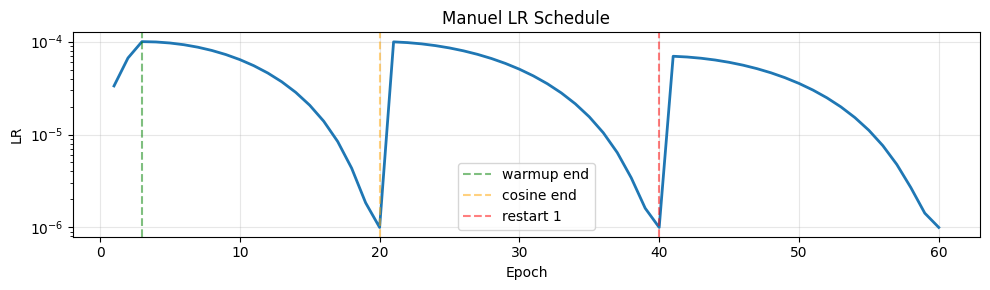

✓ KD loss: student_feat=256 → teacher_feat=512
✓ Optimizer: 4.47M trainable params
✓ EMA: decay=0.999, start epoch 5
✓ SegmentationMetrics hazır

🚀 Eğitime hazır.


In [7]:
# ============================================================
# HÜCRE 14: Manuel LR + KD loss + optimizer + EMA + metrics
# ============================================================
# Bu hücre ne yapıyor?
#   1) compute_lr(epoch) — 4 rejim manuel LR
#   2) KnowledgeDistillationLoss instance (gerçek feat kanalları ile)
#   3) AdamW optimizer (student + feat_proj params)
#   4) ModelEMA instance
#   5) SegmentationMetrics instance
#   6) LR eğrisi sanity plot
#
# Beklenen çıktı:
#   - LR eğrisi grafiği
#   - "✓ Optimizer: X M trainable params"

import math
import numpy as np
import matplotlib.pyplot as plt

# --- Hiperparametreler ---
NUM_EPOCHS = 60
LR_WARMUP_END = 3
LR_COSINE_END = 20
LR_RESTART1_END = 40
LR_RESTART2_END = 60
LR_PEAK = 1e-4
LR_RESTART2_PEAK = 7e-5
LR_MIN = 1e-6
WEIGHT_DECAY = 0.01

EMA_START_EPOCH = 5
EMA_DECAY = 0.999

KD_TEMPERATURE = 4.0
DAMAGE_CLASS_WEIGHTS = [0.05, 1.0, 8.0, 5.0, 7.0, 0.5]  # Phase 2 ile aynı

TEST_MODE = False  # True yapıp 2-3 epoch quick run ile test edebilirsin
if TEST_MODE:
    NUM_EPOCHS = 3

def compute_lr(epoch):
    """Manuel LR: 1-indexed epoch. 4 rejim."""
    e = float(epoch)
    if e <= LR_WARMUP_END:
        return LR_PEAK * (e / LR_WARMUP_END)
    elif e <= LR_COSINE_END:
        prog = (e - LR_WARMUP_END) / (LR_COSINE_END - LR_WARMUP_END)
        return LR_MIN + (LR_PEAK - LR_MIN) * 0.5 * (1 + math.cos(math.pi * prog))
    elif e <= LR_RESTART1_END:
        prog = (e - LR_COSINE_END) / (LR_RESTART1_END - LR_COSINE_END)
        return LR_MIN + (LR_PEAK - LR_MIN) * 0.5 * (1 + math.cos(math.pi * prog))
    else:
        prog = min(1.0, (e - LR_RESTART1_END) / max(1, LR_RESTART2_END - LR_RESTART1_END))
        return LR_MIN + (LR_RESTART2_PEAK - LR_MIN) * 0.5 * (1 + math.cos(math.pi * prog))

# LR eğrisi görseli
_eps = list(range(1, NUM_EPOCHS + 1))
_lrs = [compute_lr(e) for e in _eps]
plt.figure(figsize=(10, 3))
plt.plot(_eps, _lrs, linewidth=2)
plt.axvline(LR_WARMUP_END, color='g', linestyle='--', alpha=0.5, label='warmup end')
plt.axvline(LR_COSINE_END, color='orange', linestyle='--', alpha=0.5, label='cosine end')
plt.axvline(LR_RESTART1_END, color='r', linestyle='--', alpha=0.5, label='restart 1')
plt.xlabel("Epoch"); plt.ylabel("LR"); plt.yscale("log")
plt.title("Manuel LR Schedule")
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout()
plt.show()

# --- KD Loss instance (gerçek feat kanalları ile) ---
kd_loss = KnowledgeDistillationLoss(
    student_feat_channels=STUDENT_FEAT_CH,
    teacher_feat_channels=TEACHER_FEAT_CH,
    temperature=KD_TEMPERATURE,
    damage_class_weights=DAMAGE_CLASS_WEIGHTS,
).cuda()
print(f"✓ KD loss: student_feat={STUDENT_FEAT_CH} → teacher_feat={TEACHER_FEAT_CH}")

# --- Optimizer: student + feat_proj ---
trainable_params = list(student.parameters()) + list(kd_loss.feat_proj.parameters())
optimizer = torch.optim.AdamW(
    trainable_params, lr=LR_PEAK,
    weight_decay=WEIGHT_DECAY, betas=(0.9, 0.999),
)
n_trainable = sum(p.numel() for p in trainable_params) / 1e6
print(f"✓ Optimizer: {n_trainable:.2f}M trainable params")

# --- EMA ---
ema_model = ModelEMA(student, decay=EMA_DECAY)
print(f"✓ EMA: decay={EMA_DECAY}, start epoch {EMA_START_EPOCH}")

# --- Metrics ---
val_seg_metrics = SegmentationMetrics(num_classes=6)
print("✓ SegmentationMetrics hazır")

print("\n🚀 Eğitime hazır.")


## 🏋️ KD Eğitim Döngüsü

Her batch'te:

```
1. Student forward (grad ON) → student_out (dict)
2. Teacher forward (grad OFF, torch.no_grad) → teacher_out (feat_for_kd dahil)
3. KD loss hesapla (5 component)
4. loss / accum → backward
5. Accum tamamlandı mı → step + zero_grad + ema.update(student)
```

**Tahmini süre:** H100'de ~6-8 dakika/epoch × 60 epoch ≈ **6-8 saat**.

**Checkpoint:** her epoch'ta history.json yazılır. Raw best + EMA best ayrı:
- `student_v1_best.pth` (raw)
- `student_v1_best_ema.pth` (EMA — `model_state_dict` doğrudan EMA ağırlıklarını içerir, Phase 2 pattern'i ile birebir aynı)


In [8]:
# ============================================================
# HÜCRE 16: KD Training Loop
# ============================================================
# Bu hücre ne yapıyor?
#   1) NUM_EPOCHS döngüsü
#   2) Train: student forward, teacher forward (no_grad), KD loss, accum, ema.update
#   3) Validation: raw + EMA (ema.apply_to → validate → ema.restore)
#   4) Per-class IoU, mIoU_no_bg hesap
#   5) Best checkpoint save (raw ve EMA ayrı)
#   6) history.json (crash-resilient)
#
# Beklenen çıktı (her epoch):
#   "Ep 01/60 | lr 3.3e-05 | L 1.824 (h 0.9 s 0.6 f 0.3 c 0.1 d 0.0) |
#    val mIoU_nb 0.12 (ema —) | 7.2m"

import time
import json
from collections import defaultdict
from tqdm.auto import tqdm

# Checkpoint paths
BEST_RAW_PATH = os.path.join(CKPT_STUDENT, "student_v1_best.pth")
BEST_EMA_PATH = os.path.join(CKPT_STUDENT, "student_v1_best_ema.pth")
HISTORY_PATH  = os.path.join(CKPT_STUDENT, "student_v1_history.json")

GRAD_CLIP = 1.0
amp_dtype = torch.bfloat16 if PRECISION == "bf16" else torch.float16

class_names = ["bg", "no", "minor", "major", "dest", "uncls"]

history = {
    "epoch": [], "lr": [], "train_loss": [],
    "train_L_hard": [], "train_L_soft": [], "train_L_feat": [],
    "train_L_change": [], "train_L_disaster": [],
    "val_miou": [], "val_miou_no_bg": [],
    "val_miou_ema": [], "val_miou_no_bg_ema": [],
    "val_iou_per_class": [], "val_iou_per_class_ema": [],
    "epoch_time_min": [],
}
best_miou_raw = 0.0
best_miou_ema = 0.0

def _student_validate():
    """Student (current weights) ile validation."""
    student.eval()
    val_seg_metrics.reset()
    with torch.no_grad():
        for batch in val_loader:
            images = batch["image"].cuda(non_blocking=True)
            damage_mask = batch["damage_mask"].cuda(non_blocking=True)
            with torch.autocast(device_type="cuda", dtype=amp_dtype):
                out = student(images)
            preds = out["damage_logits"].argmax(dim=1)
            val_seg_metrics.update(preds, damage_mask)
    return val_seg_metrics.compute()

print(f"\n🚀 KD EĞİTİM BAŞLIYOR — {NUM_EPOCHS} epoch")
print(f"   Hedef: mIoU_no_bg ≥ 0.40 (teacher'ın %85'i)")
print("=" * 75)

for epoch in range(1, NUM_EPOCHS + 1):
    epoch_start = time.time()

    # === Manuel LR ===
    current_lr = compute_lr(epoch)
    for g in optimizer.param_groups:
        g["lr"] = current_lr

    # ====== TRAIN ======
    student.train()
    running = defaultdict(float)
    n_batches = 0
    optimizer.zero_grad(set_to_none=True)

    pbar = tqdm(train_loader, desc=f"Ep {epoch}/{NUM_EPOCHS} [tr] LR={current_lr:.1e}", leave=False)
    for batch_idx, batch in enumerate(pbar):
        if TEST_MODE and batch_idx >= 15:
            break

        images = batch["image"].cuda(non_blocking=True)
        damage_mask = batch["damage_mask"].cuda(non_blocking=True)

        with torch.autocast(device_type="cuda", dtype=amp_dtype):
            # Student forward (grad ON)
            student_out = student(images)
            # Teacher forward (grad OFF)
            with torch.no_grad():
                teacher_out = teacher_wrapper(images)
            # KD loss
            total, parts = kd_loss(student_out, teacher_out, damage_mask)
            loss_scaled = total / GRAD_ACCUM_STEPS

        loss_scaled.backward()

        if (batch_idx + 1) % GRAD_ACCUM_STEPS == 0:
            torch.nn.utils.clip_grad_norm_(trainable_params, GRAD_CLIP)
            optimizer.step()
            optimizer.zero_grad(set_to_none=True)
            if epoch >= EMA_START_EPOCH:
                ema_model.update(student)

        for k, v in parts.items():
            running[k] += v.item() if torch.is_tensor(v) else float(v)
        n_batches += 1
        pbar.set_postfix({"loss": f"{total.item():.3f}"})

    # Kalan accum
    if (n_batches % GRAD_ACCUM_STEPS) != 0:
        torch.nn.utils.clip_grad_norm_(trainable_params, GRAD_CLIP)
        optimizer.step()
        optimizer.zero_grad(set_to_none=True)
        if epoch >= EMA_START_EPOCH:
            ema_model.update(student)

    means = {k: v / max(n_batches, 1) for k, v in running.items()}

    # ====== VAL (raw) ======
    val_scores_raw = _student_validate()

    # ====== VAL (EMA) ======
    val_scores_ema = None
    if epoch >= EMA_START_EPOCH:
        backup = ema_model.apply_to(student)
        val_scores_ema = _student_validate()
        ema_model.restore(student, backup)
    student.train()  # eğitime dön

    epoch_time = (time.time() - epoch_start) / 60.0

    # History
    history["epoch"].append(epoch)
    history["lr"].append(current_lr)
    history["train_loss"].append(means.get("L_total", 0.0))
    history["train_L_hard"].append(means.get("L_hard", 0.0))
    history["train_L_soft"].append(means.get("L_soft", 0.0))
    history["train_L_feat"].append(means.get("L_feat", 0.0))
    history["train_L_change"].append(means.get("L_change", 0.0))
    history["train_L_disaster"].append(means.get("L_disaster", 0.0))
    history["val_miou"].append(float(val_scores_raw["miou"]))
    history["val_miou_no_bg"].append(float(val_scores_raw["miou_no_bg"]))
    history["val_iou_per_class"].append([float(x) if x==x else None for x in val_scores_raw["iou_per_class"]])
    if val_scores_ema:
        history["val_miou_ema"].append(float(val_scores_ema["miou"]))
        history["val_miou_no_bg_ema"].append(float(val_scores_ema["miou_no_bg"]))
        history["val_iou_per_class_ema"].append([float(x) if x==x else None for x in val_scores_ema["iou_per_class"]])
    else:
        history["val_miou_ema"].append(None)
        history["val_miou_no_bg_ema"].append(None)
        history["val_iou_per_class_ema"].append(None)
    history["epoch_time_min"].append(epoch_time)

    # Log
    ema_str = ""
    if val_scores_ema:
        ema_str = f" (ema {val_scores_ema['miou_no_bg']:.3f})"
    print(
        f"Ep {epoch:2d}/{NUM_EPOCHS} | lr {current_lr:.1e} | "
        f"L {means['L_total']:.3f} "
        f"(h {means['L_hard']:.2f} s {means['L_soft']:.2f} "
        f"f {means['L_feat']:.2f} c {means['L_change']:.2f} "
        f"d {means['L_disaster']:.2f}) | "
        f"val mIoU_nb {val_scores_raw['miou_no_bg']:.3f}{ema_str} | "
        f"{epoch_time:.1f}m"
    )

    # Her 5 epoch'ta per-class
    if epoch % 5 == 0 or epoch == 1:
        pc = val_scores_raw["iou_per_class"]
        print("   per-class:", " ".join(f"{n}={v:.2f}" for n, v in zip(class_names, pc)))

    # Best RAW
    if val_scores_raw["miou_no_bg"] > best_miou_raw:
        best_miou_raw = val_scores_raw["miou_no_bg"]
        torch.save({
            "epoch": epoch,
            "model_state_dict": student.state_dict(),
            "feat_proj_state_dict": kd_loss.feat_proj.state_dict(),
            "val_miou_no_bg": float(best_miou_raw),
            "val_iou_per_class": [float(x) if x==x else None for x in val_scores_raw["iou_per_class"]],
            "config": {
                "image_size": IMAGE_SIZE, "batch": BATCH_SIZE,
                "accum": GRAD_ACCUM_STEPS, "temperature": KD_TEMPERATURE,
            },
        }, BEST_RAW_PATH)
        print(f"   💾 Best RAW: {best_miou_raw:.4f}")

    # Best EMA (Phase 2 pattern'i: apply_to → save → restore)
    if val_scores_ema and val_scores_ema["miou_no_bg"] > best_miou_ema:
        best_miou_ema = val_scores_ema["miou_no_bg"]
        backup = ema_model.apply_to(student)
        torch.save({
            "epoch": epoch,
            "model_state_dict": student.state_dict(),  # artık EMA weights
            "val_miou_no_bg": float(best_miou_ema),
            "val_iou_per_class": [float(x) if x==x else None for x in val_scores_ema["iou_per_class"]],
        }, BEST_EMA_PATH)
        ema_model.restore(student, backup)
        print(f"   💾 Best EMA: {best_miou_ema:.4f}")

    # History dump (crash-resilient)
    with open(HISTORY_PATH, "w") as f:
        json.dump(history, f, indent=2)

print("\n" + "=" * 75)
print(f"🎉 KD EĞİTİM TAMAMLANDI")
print(f"   Best RAW mIoU_no_bg: {best_miou_raw:.4f}")
print(f"   Best EMA mIoU_no_bg: {best_miou_ema:.4f}")
_final = max(best_miou_raw, best_miou_ema)
print(f"   Hedef (0.40): {'✅ BAŞARILI' if _final >= 0.40 else '⚠️  altında'}")



🚀 KD EĞİTİM BAŞLIYOR — 60 epoch
   Hedef: mIoU_no_bg ≥ 0.40 (teacher'ın %85'i)


Ep 1/60 [tr] LR=3.3e-05:   0%|          | 0/802 [00:26<?, ?it/s]

Ep  1/60 | lr 3.3e-05 | L 5249165.886 (h 0.72 s 12201622.15 f 0.77 c 3685159.15 d 18.21) | val mIoU_nb 0.059 | 29.5m
   per-class: bg=0.95 no=0.30 minor=0.00 major=0.00 dest=0.00 uncls=0.00
   💾 Best RAW: 0.0592


Ep 2/60 [tr] LR=6.7e-05:   0%|          | 0/802 [00:00<?, ?it/s]

Ep  2/60 | lr 6.7e-05 | L 4173610.180 (h 0.73 s 9760268.98 f 0.77 c 2695013.38 d 17.67) | val mIoU_nb 0.064 | 10.8m
   💾 Best RAW: 0.0640


...

Ep 58/60 | lr 2.7e-06 | L 60485.763 (h 0.36 s 140066.52 f 0.35 c 44588.61 d 2.71) | val mIoU_nb 0.437 (ema 0.436) | 7.4m
   💾 Best EMA: 0.4364


Ep 59/60 [tr] LR=1.4e-06:   0%|          | 0/802 [00:00<?, ?it/s]

Ep 59/60 | lr 1.4e-06 | L 61520.426 (h 0.36 s 142639.58 f 0.35 c 44642.98 d 2.66) | val mIoU_nb 0.441 (ema 0.438) | 7.5m
   💾 Best EMA: 0.4382


Ep 60/60 [tr] LR=1.0e-06:   0%|          | 0/802 [00:00<?, ?it/s]

Ep 60/60 | lr 1.0e-06 | L 58941.446 (h 0.35 s 136419.66 f 0.34 c 43732.98 d 2.54) | val mIoU_nb 0.439 (ema 0.436) | 7.3m
   per-class: bg=0.99 no=0.66 minor=0.27 major=0.39 dest=0.58 uncls=0.29

🎉 KD EĞİTİM TAMAMLANDI
   Best RAW mIoU_no_bg: 0.4462
   Best EMA mIoU_no_bg: 0.4382
   Hedef (0.40): ✅ BAŞARILI


## 📈 Eğitim Eğrileri ve Öğretmenle Karşılaştırma

4 panel:

1. **Train loss + LR**
2. **Component losses** (5 component)
3. **Val mIoU_no_bg** (raw vs EMA + hedef + teacher referansı)
4. **Per-class IoU** (teacher vs student bar chart)

Teacher referans (Phase 2 v4):
`bg=0.99, no=0.70, minor=0.28, major=0.44, destroyed=0.62, uncls=0.31, mIoU_no_bg=0.470`


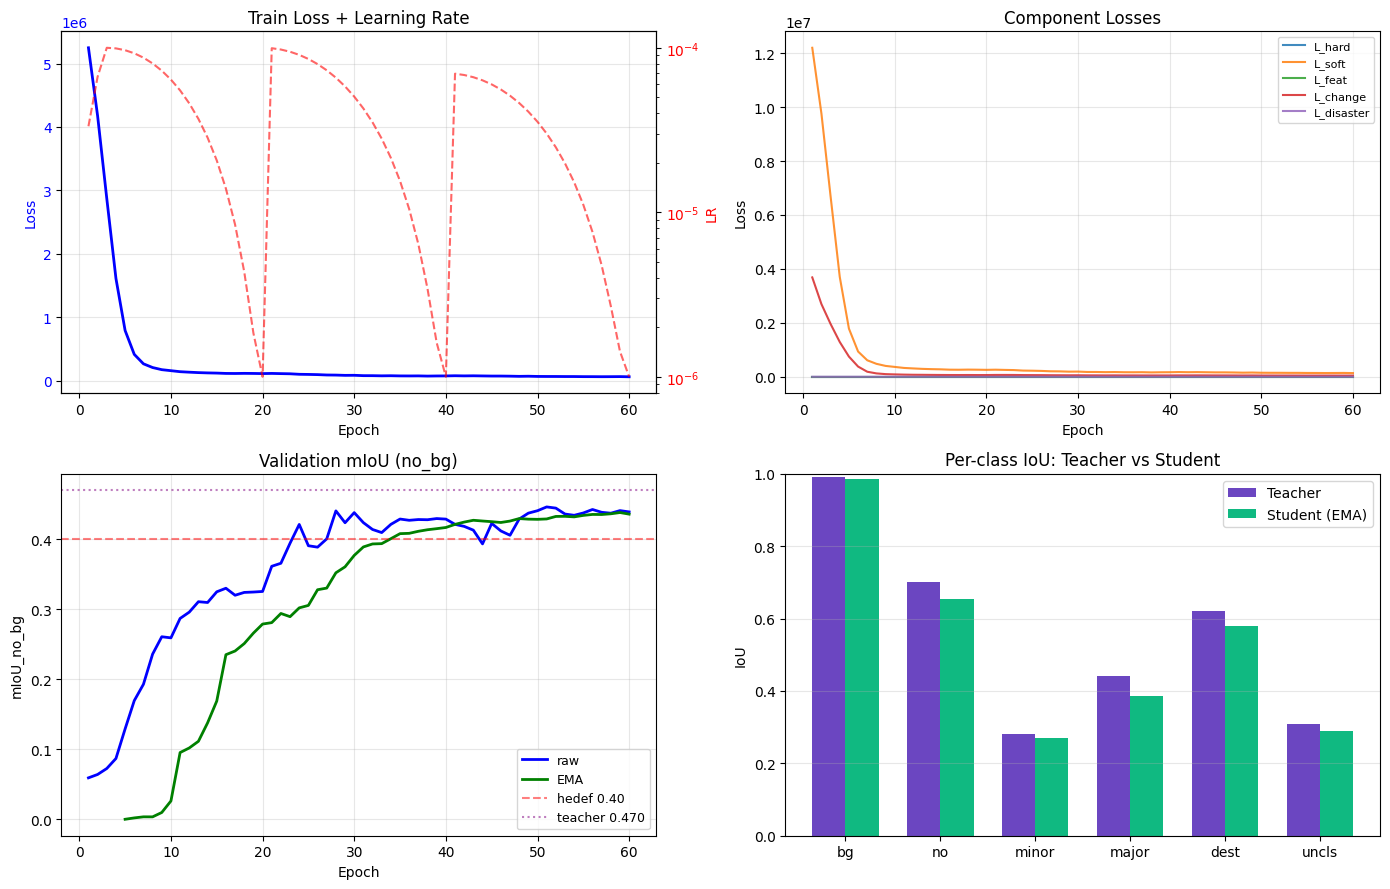

✓ Kaydedildi: /content/drive/MyDrive/AFETSONAR/outputs/visualizations/student_v1_training_curves.png

FINAL KARŞILAŞTIRMA
Sınıf           Teacher    Student       Fark
bg                0.990      0.987     -0.003
no                0.700      0.655     -0.045
minor             0.280      0.271     -0.009
major             0.440      0.387     -0.053
dest              0.620      0.578     -0.042
uncls             0.310      0.288     -0.022
mIoU_no_bg        0.470      0.436     -0.034

🎯 Hedef (%85): 0.400 | Ulaşılan: 0.436
   ✅ BAŞARILI


In [9]:
# ============================================================
# HÜCRE 18: Training curves + per-class comparison
# ============================================================
# Bu hücre ne yapıyor?
#   1) history.json'ı okur
#   2) 4 panel grafik: loss+LR, components, mIoU, per-class
#   3) student_v1_training_curves.png kaydet
#   4) Özet tablo yazdır

import json
import numpy as np
import matplotlib.pyplot as plt

with open(HISTORY_PATH) as f:
    H = json.load(f)

epochs = H["epoch"]
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

# (1) Train loss + LR
ax = axes[0, 0]
ax.plot(epochs, H["train_loss"], "b-", linewidth=2, label="Train Loss")
ax.set_xlabel("Epoch"); ax.set_ylabel("Loss", color="b")
ax.tick_params(axis="y", labelcolor="b")
ax2 = ax.twinx()
ax2.plot(epochs, H["lr"], "r--", alpha=0.6, label="LR")
ax2.set_ylabel("LR", color="r"); ax2.set_yscale("log")
ax2.tick_params(axis="y", labelcolor="r")
ax.set_title("Train Loss + Learning Rate")
ax.grid(alpha=0.3)

# (2) Component losses
ax = axes[0, 1]
for k, label, c in [
    ("train_L_hard",     "L_hard",     "C0"),
    ("train_L_soft",     "L_soft",     "C1"),
    ("train_L_feat",     "L_feat",     "C2"),
    ("train_L_change",   "L_change",   "C3"),
    ("train_L_disaster", "L_disaster", "C4"),
]:
    ax.plot(epochs, H[k], label=label, color=c, alpha=0.85)
ax.set_xlabel("Epoch"); ax.set_ylabel("Loss")
ax.set_title("Component Losses")
ax.legend(fontsize=8); ax.grid(alpha=0.3)

# (3) Val mIoU_no_bg raw vs ema
ax = axes[1, 0]
ax.plot(epochs, H["val_miou_no_bg"], "b-", linewidth=2, label="raw")
ema_vals = [(e, v) for e, v in zip(epochs, H["val_miou_no_bg_ema"]) if v is not None]
if ema_vals:
    ee, ev = zip(*ema_vals)
    ax.plot(ee, ev, "g-", linewidth=2, label="EMA")
ax.axhline(0.40, color="r", linestyle="--", alpha=0.5, label="hedef 0.40")
ax.axhline(0.470, color="purple", linestyle=":", alpha=0.5, label="teacher 0.470")
ax.set_xlabel("Epoch"); ax.set_ylabel("mIoU_no_bg")
ax.set_title("Validation mIoU (no_bg)")
ax.legend(loc="lower right", fontsize=9); ax.grid(alpha=0.3)

# (4) Per-class IoU bar chart
ax = axes[1, 1]
# Son epoch per-class (EMA tercih, yoksa raw)
if H["val_iou_per_class_ema"][-1] is not None:
    final_pc = H["val_iou_per_class_ema"][-1]
    source = "EMA"
else:
    final_pc = H["val_iou_per_class"][-1]
    source = "raw"
teacher_pc = [0.99, 0.70, 0.28, 0.44, 0.62, 0.31]  # Phase 2 v4
x = np.arange(6)
w = 0.35
ax.bar(x - w/2, teacher_pc, w, label="Teacher", color="#6b46c1")
student_pc = [0.0 if v is None else v for v in final_pc]
ax.bar(x + w/2, student_pc, w, label=f"Student ({source})", color="#10b981")
ax.set_xticks(x)
ax.set_xticklabels(class_names)
ax.set_ylabel("IoU"); ax.set_ylim(0, 1.0)
ax.set_title("Per-class IoU: Teacher vs Student")
ax.legend(); ax.grid(alpha=0.3, axis="y")

plt.tight_layout()
curve_path = os.path.join(OUTPUTS_VIZ, "student_v1_training_curves.png")
plt.savefig(curve_path, dpi=120, bbox_inches="tight")
plt.show()
print(f"✓ Kaydedildi: {curve_path}")

# Özet tablo
print("\n" + "=" * 60)
print("FINAL KARŞILAŞTIRMA")
print("=" * 60)
print(f"{'Sınıf':<12s} {'Teacher':>10s} {'Student':>10s} {'Fark':>10s}")
for i, c in enumerate(class_names):
    t = teacher_pc[i]
    s = student_pc[i]
    print(f"{c:<12s} {t:>10.3f} {s:>10.3f} {s-t:>+10.3f}")
miou_t = float(np.mean(teacher_pc[1:]))
miou_s = float(np.mean([v for v in student_pc[1:] if v > 0]))
print(f"{'mIoU_no_bg':<12s} {miou_t:>10.3f} {miou_s:>10.3f} {miou_s-miou_t:>+10.3f}")
print(f"\n🎯 Hedef (%85): {0.85*miou_t:.3f} | Ulaşılan: {miou_s:.3f}")
print(f"   {'✅ BAŞARILI' if miou_s >= 0.85*miou_t else '⚠️  Hedefin altında'}")


## 🖼️ Öğrenci Tahminleri — Teacher / Student Yan Yana

Val setinden 4 örnek:

| Sütun | İçerik |
|-------|--------|
| 1 | Pre-disaster |
| 2 | Post-disaster |
| 3 | Ground truth damage |
| 4 | Teacher prediction |
| 5 | Student (EMA) prediction |

6-sınıf colormap Phase 2 notebook'u ile birebir aynı:  
⚫ bg · 🟢 no · 🟡 minor · 🟠 major · 🔴 destroyed · 🟣 uncls


In [ ]:
# ============================================================
# HÜCRE 20: Sample predictions — Teacher vs Student
# ============================================================
# Bu hücre ne yapıyor?
#   1) Best EMA student checkpoint'i yükle
#   2) 4 val örneği için pre, post, GT, teacher pred, student pred çıkar
#   3) 4x5 grid matplotlib figure
#   4) PNG kaydet

import random
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

# Phase 2 ile aynı colormap
CMAP_V2 = ListedColormap(np.array([
    [0, 0, 0], [0, 255, 0], [255, 255, 0],
    [255, 128, 0], [255, 0, 0], [200, 0, 200]
]) / 255.0)

# Best EMA student'ı yükle
if os.path.exists(BEST_EMA_PATH):
    print("📂 Best EMA student yükleniyor...")
    student_ckpt = torch.load(BEST_EMA_PATH, map_location="cpu", weights_only=False)
    student.load_state_dict(student_ckpt["model_state_dict"])
    print(f"   epoch={student_ckpt['epoch']}, val_miou_no_bg={student_ckpt['val_miou_no_bg']:.4f}")
else:
    print("📂 Best RAW student yükleniyor (EMA yok)...")
    student_ckpt = torch.load(BEST_RAW_PATH, map_location="cpu", weights_only=False)
    student.load_state_dict(student_ckpt["model_state_dict"])
student = student.cuda().eval()

# Denormalize helper (Phase 2 ile aynı)
def _denorm(img_tensor):
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    x = img_tensor.detach().cpu() * std + mean
    return x.clamp(0, 1).permute(1, 2, 0).numpy()

random.seed(42)
N_SAMPLES = 4
sample_indices = random.sample(range(len(val_ds)), N_SAMPLES)

fig, axes = plt.subplots(N_SAMPLES, 5, figsize=(22, 4.4 * N_SAMPLES))

for row, idx in enumerate(sample_indices):
    sample = val_ds[idx]
    img6 = sample["image"].unsqueeze(0).cuda()  # [1, 6, H, W]
    gt = sample["mask"].numpy()

    with torch.no_grad(), torch.autocast(device_type="cuda", dtype=amp_dtype):
        t_out = teacher_wrapper(img6)
        s_out = student(img6)

    t_pred = t_out["damage_logits"].argmax(dim=1)[0].cpu().numpy()
    s_pred = s_out["damage_logits"].argmax(dim=1)[0].cpu().numpy()

    pre_img  = _denorm(sample["image"][:3])
    post_img = _denorm(sample["image"][3:])

    imgs = [pre_img, post_img, gt, t_pred, s_pred]
    titles = ["Pre", "Post", "Ground Truth", "Teacher", f"Student (EMA)"]
    for col, (img, ttl) in enumerate(zip(imgs, titles)):
        ax = axes[row, col]
        if col < 2:
            ax.imshow(img)
        else:
            ax.imshow(img, cmap=CMAP_V2, vmin=0, vmax=5)
        if row == 0:
            ax.set_title(ttl, fontsize=12)
        ax.axis("off")

plt.suptitle(f"Student v1 — Phase 3 KD (mIoU_no_bg: {student_ckpt['val_miou_no_bg']:.4f})",
             fontsize=14, y=1.001)
plt.tight_layout()
pred_path = os.path.join(OUTPUTS_VIZ, "student_v1_predictions.png")
plt.savefig(pred_path, dpi=90, bbox_inches="tight")
plt.show()
print(f"✓ Kaydedildi: {pred_path}")

# Aynı dosyadan ikinci kopya (teacher_comparison)
comp_path = os.path.join(OUTPUTS_VIZ, "student_v1_teacher_comparison.png")
plt.savefig(comp_path, dpi=90, bbox_inches="tight")
plt.close()
print(f"✓ Kaydedildi: {comp_path}")


## ⚡ Model Boyutu ve Hız Karşılaştırması

KD'nin asıl vaadi — **küçük ve hızlı**:

1. **Parametre sayısı** (M)
2. **Checkpoint boyutu** (MB)
3. **Inference latency** (ms/sample, bs=1, 768², bf16)
4. **Throughput** (img/s)

Drone deployment için **bs=1 latency** önemli. <50ms real-time sayılır.


In [ ]:
# ============================================================
# HÜCRE 22: Boyut ve hız karşılaştırması
# ============================================================
# Bu hücre ne yapıyor?
#   1) Params (M), checkpoint MB
#   2) Latency: warmup 10 + timed 50 iter
#   3) Throughput
#   4) Karşılaştırma tablosu + bar chart

import time
import matplotlib.pyplot as plt

def count_params(m):
    return sum(p.numel() for p in m.parameters()) / 1e6

def file_mb(path):
    return os.path.getsize(path) / 1e6 if os.path.exists(path) else 0.0

def bench_latency(model_eval, n_warmup=10, n_iter=50):
    model_eval.eval()
    x = torch.randn(1, 6, IMAGE_SIZE, IMAGE_SIZE, device="cuda")
    with torch.no_grad(), torch.autocast(device_type="cuda", dtype=amp_dtype):
        for _ in range(n_warmup):
            _ = model_eval(x)
    torch.cuda.synchronize()
    t0 = time.time()
    with torch.no_grad(), torch.autocast(device_type="cuda", dtype=amp_dtype):
        for _ in range(n_iter):
            _ = model_eval(x)
    torch.cuda.synchronize()
    return (time.time() - t0) / n_iter * 1000.0  # ms

teacher_params = count_params(teacher)
student_params = count_params(student)

teacher_mb = file_mb(TEACHER_CKPT_PATH)
student_mb = file_mb(BEST_EMA_PATH) or file_mb(BEST_RAW_PATH)

print("⏱️  Teacher latency ölçülüyor...")
teacher_ms = bench_latency(teacher_wrapper)
print("⏱️  Student latency ölçülüyor...")
student_ms = bench_latency(student)

compression = teacher_params / max(student_params, 1e-6)
speedup = teacher_ms / max(student_ms, 1e-6)

print("\n" + "=" * 60)
print(f"{'Metric':<25s} {'Teacher':>15s} {'Student':>15s}")
print("=" * 60)
print(f"{'Parametre (M)':<25s} {teacher_params:>15.2f} {student_params:>15.2f}")
print(f"{'Checkpoint (MB)':<25s} {teacher_mb:>15.1f} {student_mb:>15.1f}")
print(f"{'Latency (ms, bs=1)':<25s} {teacher_ms:>15.2f} {student_ms:>15.2f}")
print(f"{'Throughput (img/s)':<25s} {1000/teacher_ms:>15.2f} {1000/student_ms:>15.2f}")
print("=" * 60)
print(f"📉 Compression: {compression:.1f}×")
print(f"⚡ Speedup:     {speedup:.1f}×")
print(f"🎯 Real-time (<50ms): {'✅' if student_ms < 50 else '⚠️'}  student = {student_ms:.1f} ms")

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
names = ["Teacher", "Student"]
colors = ["#6b46c1", "#10b981"]
axes[0].bar(names, [teacher_params, student_params], color=colors)
axes[0].set_title("Params (M)"); axes[0].grid(alpha=0.3, axis="y")
axes[1].bar(names, [teacher_mb, student_mb], color=colors)
axes[1].set_title("Checkpoint (MB)"); axes[1].grid(alpha=0.3, axis="y")
axes[2].bar(names, [teacher_ms, student_ms], color=colors)
axes[2].axhline(50, color="r", linestyle="--", alpha=0.5, label="real-time 50ms")
axes[2].set_title("Latency (ms/img)"); axes[2].legend(); axes[2].grid(alpha=0.3, axis="y")
plt.tight_layout()
speed_path = os.path.join(OUTPUTS_VIZ, "student_v1_size_speed.png")
plt.savefig(speed_path, dpi=120, bbox_inches="tight")
plt.show()
print(f"✓ Kaydedildi: {speed_path}")

print("\n🎉 Notebook 3 tamamlandı!")
print(f"📦 Çıktılar ({CKPT_STUDENT}):")
for p in [BEST_RAW_PATH, BEST_EMA_PATH, HISTORY_PATH]:
    if os.path.exists(p):
        print(f"   - {os.path.basename(p)}")
print(f"📊 Görseller ({OUTPUTS_VIZ}):")
for p in ["student_v1_training_curves.png", "student_v1_predictions.png",
          "student_v1_teacher_comparison.png", "student_v1_size_speed.png"]:
    if os.path.exists(os.path.join(OUTPUTS_VIZ, p)):
        print(f"   - {p}")
